## A cascade from one initial startle

One fish starts actively escaping at time zero. All other fish begin
unsheltered, with zero evidence. Subsequent escapes are driven by social doses.

While susceptible, each fish's evidence is the sum of doses remembered
within `memory_duration`. An unsheltered fish escapes when this exceeds its own
fixed threshold, stored as `fish.threshold`.
It sends doses for `active_duration`, then enters absorbing shelter.

The states are `0` (unsheltered), `1` (active), and `2` (sheltered).
Each fish can escape at most once during a run.

Parameters, initialization, the update loop, and plots are shown below.
Run the notebook from the top to initialize a fresh school.
[dose_memory.ipynb](dose_memory.ipynb) explains the dose and memory functions.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import agent
import stimulus

from agent import Agent
from stimulus import spontaneous_startle
from dose import draw_doses, accumulate_doses
from network import random_directed_network

In [2]:
## Group size and timestep
n_fish = 20
dt = 0.001

## Mean escape threshold and active phase
mean_threshold = 0.10
active_duration = 0.5
random_seed = 2026

## Social dose arrivals and memory
dose_rate = 1000.0
dose_size = 0.001
memory_duration = 2.0

Each fish can be active only once. The sum of all possible active phases
therefore bounds the cascade duration by `n_fish * active_steps` updates.
`max_steps` reserves that many updates plus the initial state. This is
storage capacity; the run ends as soon as no active fish remain.

After stopping, `n_steps` counts the recorded samples, including the
initial state and the final inactive state. Time and history columns
run from zero through `n_steps - 1`.


In [3]:
active_steps = round(active_duration / dt)
memory_steps = round(memory_duration / dt)
max_steps = n_fish * active_steps + 1


## Social interactions

`adjacency[i, j]` is the connection weight from sender fish `j` to receiver fish `i`. The network is directed, with binary weights and no self-input. `adjacency.sum(axis=1)` gives each fish's in-degree.

`random_directed_network` creates a shuffled directed cycle and adds random links until there are `round(n_fish * mean_in_degree)` links. Individual in-degrees can vary, but every fish has at least one incoming link and a directed path to every other fish. The realized mean is the total number of links divided by `n_fish`. Use `1 <= mean_in_degree <= n_fish - 1`. `network_seed` controls network construction independently of starter selection and dose arrivals.

An active neighbour sends a packet with probability `dose_rate * adjacency[i, j] * dt`. Each packet contributes `dose_size` divided by the receiver's number of incoming neighbours, including inactive neighbours. With the current binary weights and dose settings, each active connection supplies a packet every update. The network stays fixed during the cascade.


In [4]:
mean_in_degree = 3
network_seed = 2026


In [5]:
adjacency = random_directed_network(n_fish, mean_in_degree, network_seed)


In [6]:
evidence_history = np.zeros((n_fish, max_steps))
escape_spikes = np.zeros((n_fish, max_steps))
state_history = np.zeros((n_fish, max_steps))
dose_history = np.zeros((n_fish, max_steps))

## Individual escape thresholds

Each fish receives one threshold drawn uniformly between zero and
`2 * mean_threshold`. Its threshold stays fixed throughout the run.

`mean_threshold = 0.10` is an exploratory setting for the connected binary
random network, chosen to allow more evidence to accumulate before escape.
It is the distribution's expected mean, not the average received dose
or necessarily the mean of this particular sample. The distribution
still includes thresholds near zero, so not every fish has a substantial
minimum evidence requirement.

Sosna et al.'s baseline fit of 0.034 (SI section 6.3, page 9) applies to
their empirical probability-weighted networks. The setting used here
is not fitted to experimental cascade sizes.

The threshold generator is separate from the starter and dose generators.
Rerunning from the top with the same seed reproduces the same thresholds.


In [7]:
threshold_rng = np.random.default_rng([random_seed, 2])
thresholds = threshold_rng.uniform(0.0, 2 * mean_threshold, n_fish)

## One initial startle

`spontaneous_startle` in [stimulus.py](stimulus.py) sets one fish's state to
active, gives it the full active timer, and returns its index.

`initial_fish = None` selects a random fish. An integer selects that fish
instead, which allows a known experimental starter to be used later.
This function is called once, during initialization. Its random generator is
separate from the dose generator, so starter selection does not consume dose draws.


In [8]:
agents = [Agent(threshold) for threshold in thresholds]
startle_rng = np.random.default_rng([random_seed, 0])
dose_rng = np.random.default_rng([random_seed, 1])

In [9]:
initial_fish = None
starter_id = spontaneous_startle(agents, active_steps, startle_rng, initial_fish)
state_history[:, 0] = [fish.state for fish in agents]
escape_spikes[starter_id, 0] = 1

## Propagate the cascade

Doses use the active states from the preceding column. A newly activated fish
first supplies doses on the next update. For an onset at column `k`, the fish
is recorded active through `k + active_steps - 1`, sends doses on updates
`k + 1` through `k + active_steps`, then enters shelter.

Each dose retains its full contribution for `memory_steps` updates.
Only fish that are susceptible at the start of an update receive doses
and update their evidence. A fish receives the dose that triggers its
escape, then keeps that evidence value for the remainder of the run.
Active fish send doses but receive none; sheltered fish neither send
nor receive doses.

After all fish have been updated and recorded, the loop checks whether
any fish is still active. A fish activated during this update keeps
the cascade running, even if the previous active fish just sheltered.
The simulation stops on the first update with no active fish.


In [10]:
for step in range(1, max_steps):
    active = np.array([fish.state == 1 for fish in agents])
    susceptible = np.array([fish.state == 0 for fish in agents])
    dose_history[:, step] = susceptible * draw_doses(
        adjacency, active, dt, dose_rate, dose_size, dose_rng,
    )
    social_evidence = accumulate_doses(dose_history, step, memory_steps)
    for fish_id, fish in enumerate(agents):
        if fish.state == 0:
            fish.evidence = social_evidence[fish_id]
            if fish.evidence > fish.threshold:
                fish.state = 1
                fish.active_timer = active_steps
                escape_spikes[fish_id, step] = 1
        elif fish.state == 1:
            fish.active_timer -= 1
            if fish.active_timer == 0:
                fish.state = 2
        evidence_history[fish_id, step] = fish.evidence
        state_history[fish_id, step] = fish.state
    if not any(fish.state == 1 for fish in agents):
        break


Keep every sample through the stopping update and remove unused storage.


In [11]:
n_steps = step + 1
evidence_history = evidence_history[:, :n_steps]
escape_spikes = escape_spikes[:, :n_steps]
state_history = state_history[:, :n_steps]
dose_history = dose_history[:, :n_steps]


In [12]:
time = np.arange(n_steps) * dt
print(f"Cascade ended at {time[-1]:.3f} s; {int(escape_spikes.sum())} fish escaped")


Cascade ended at 1.287 s; 20 fish escaped


## Social evidence over time

The starter is activated directly, so it does not need to cross the threshold.
Other fish escape only when their remembered social evidence exceeds their
own threshold. There is no shared threshold line; `thresholds` contains the
fixed values in fish-index order.

Each trace updates only while the fish is susceptible, then stays at
the evidence value that triggered its escape. This value can overshoot
the threshold by the doses received in its final susceptible update.
The initial starter is forced active and retains zero evidence.
Flat traces after escape show stored activation values, not ongoing
evidence integration.


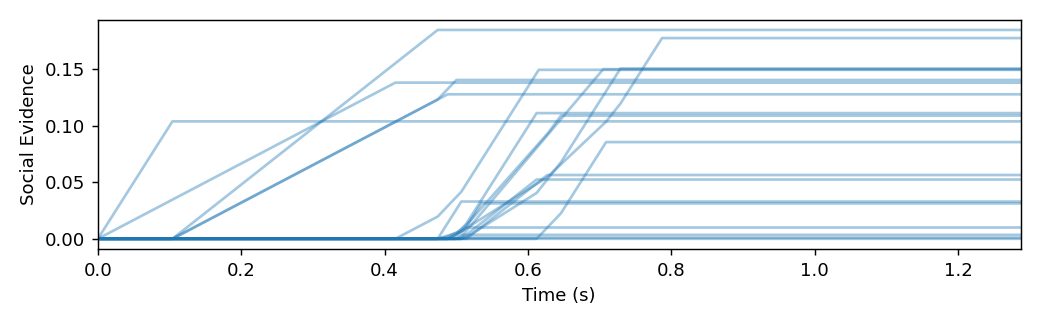

In [13]:
fig, ax = plt.subplots(figsize=(8, 2.5))
lines = ax.plot(time, evidence_history.T, color="tab:blue", alpha=0.4)
lines[0].set_label("Social evidence")
ax.set(xlim=(0, time[-1]), xlabel="Time (s)", ylabel="Social Evidence")
fig.tight_layout()
plt.show()

## Escape onsets

The mark at time zero is the initial startle. Later marks are responses to
social doses. Each fish can have at most one mark during the run.


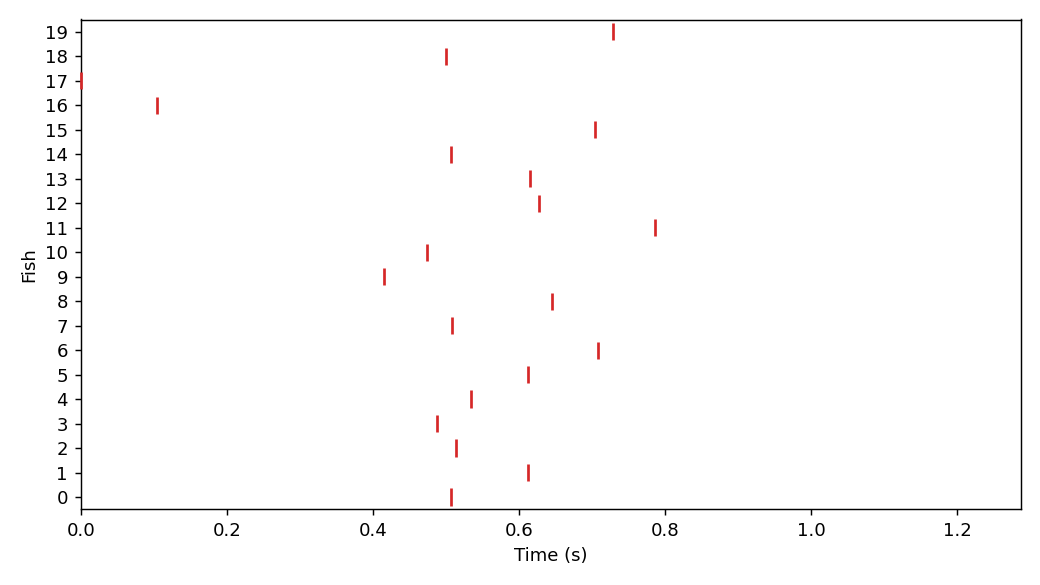

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for fish_id in range(n_fish):
    escape_times = time[escape_spikes[fish_id] == 1]
    ax.vlines(escape_times, fish_id - 0.35, fish_id + 0.35, color="tab:red",
              zorder=3, clip_on=False)
ax.set(xlim=(0, time[-1]), ylim=(-0.5, n_fish - 0.5))
ax.set(xlabel="Time (s)", ylabel="Fish", yticks=np.arange(n_fish))
fig.tight_layout()
plt.show()

## Behavioral state

Only active fish send doses. Once a fish enters shelter, it stays sheltered. The final column records the first state with no
active fish. Fish that never escaped remain unsheltered.

The run uses an exploratory mean threshold and a strongly connected directed random
network. The [guide](README.md#reproducing-sosna-et-al-2019) lists the
remaining steps toward reproducing Sosna's results.


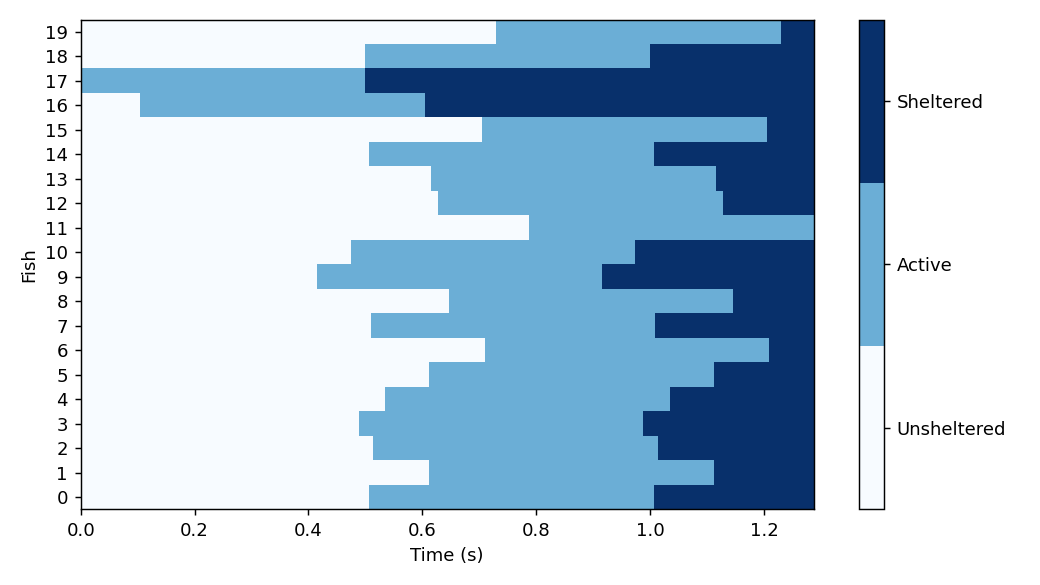

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
image = ax.imshow(state_history, origin="lower", aspect="auto",
                  extent=(-dt / 2, time[-1] + dt / 2, -0.5, n_fish - 0.5),
                  cmap=plt.get_cmap("Blues", 3), vmin=-0.5, vmax=2.5,
                  interpolation="nearest")
ax.set(xlim=(0, time[-1]), xlabel="Time (s)", ylabel="Fish",
       yticks=np.arange(n_fish))
colorbar = fig.colorbar(image, ax=ax, ticks=[0, 1, 2])
colorbar.ax.set_yticklabels(["Unsheltered", "Active", "Sheltered"])
fig.tight_layout()
plt.show()